In [48]:
import select_files
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [59]:
import re
sys_path = r'C:\Users\natak\OneDrive - Imperial College London\Documents\University\Year 4\MSci Project-r018104\All_data'
files, metas = select_files.open_img_files([['20240807_140645','20240807_140930']], sys_path)

r = re.compile(".*NA1")
img_files = list(filter(r.match, files))


r = re.compile(".*NA0")
pump_files = list(filter(r.match, files))

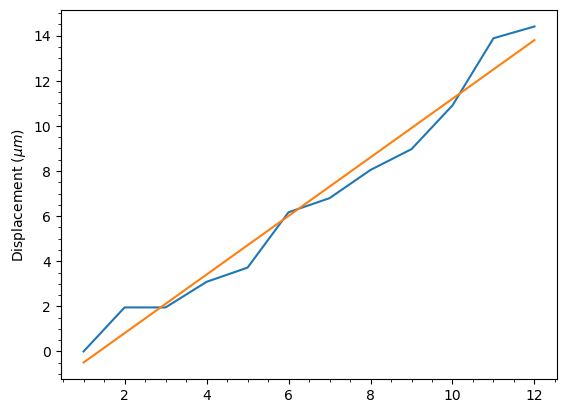

In [60]:
positions = []
for pump in pump_files:
    im = cv2.imread(pump, 0)
    
    ravel_arg = np.argmax(im)
    cx, cy = np.unravel_index(ravel_arg, im.shape)
    positions.append([cx, cy])

positions = np.array(positions)
positions = np.array(positions - positions[0])

disps = np.linalg.norm(positions, axis=1)
disps = disps*3.45/5

x = np.linspace(1, 12, 12)
popt = np.polyfit(x, disps, deg=1)
fit = np.poly1d(popt)


plt.plot(x, disps)
plt.plot(x, fit(x))
plt.ylabel(r'Displacement ($\mu m$)')
plt.minorticks_on()
plt.show()


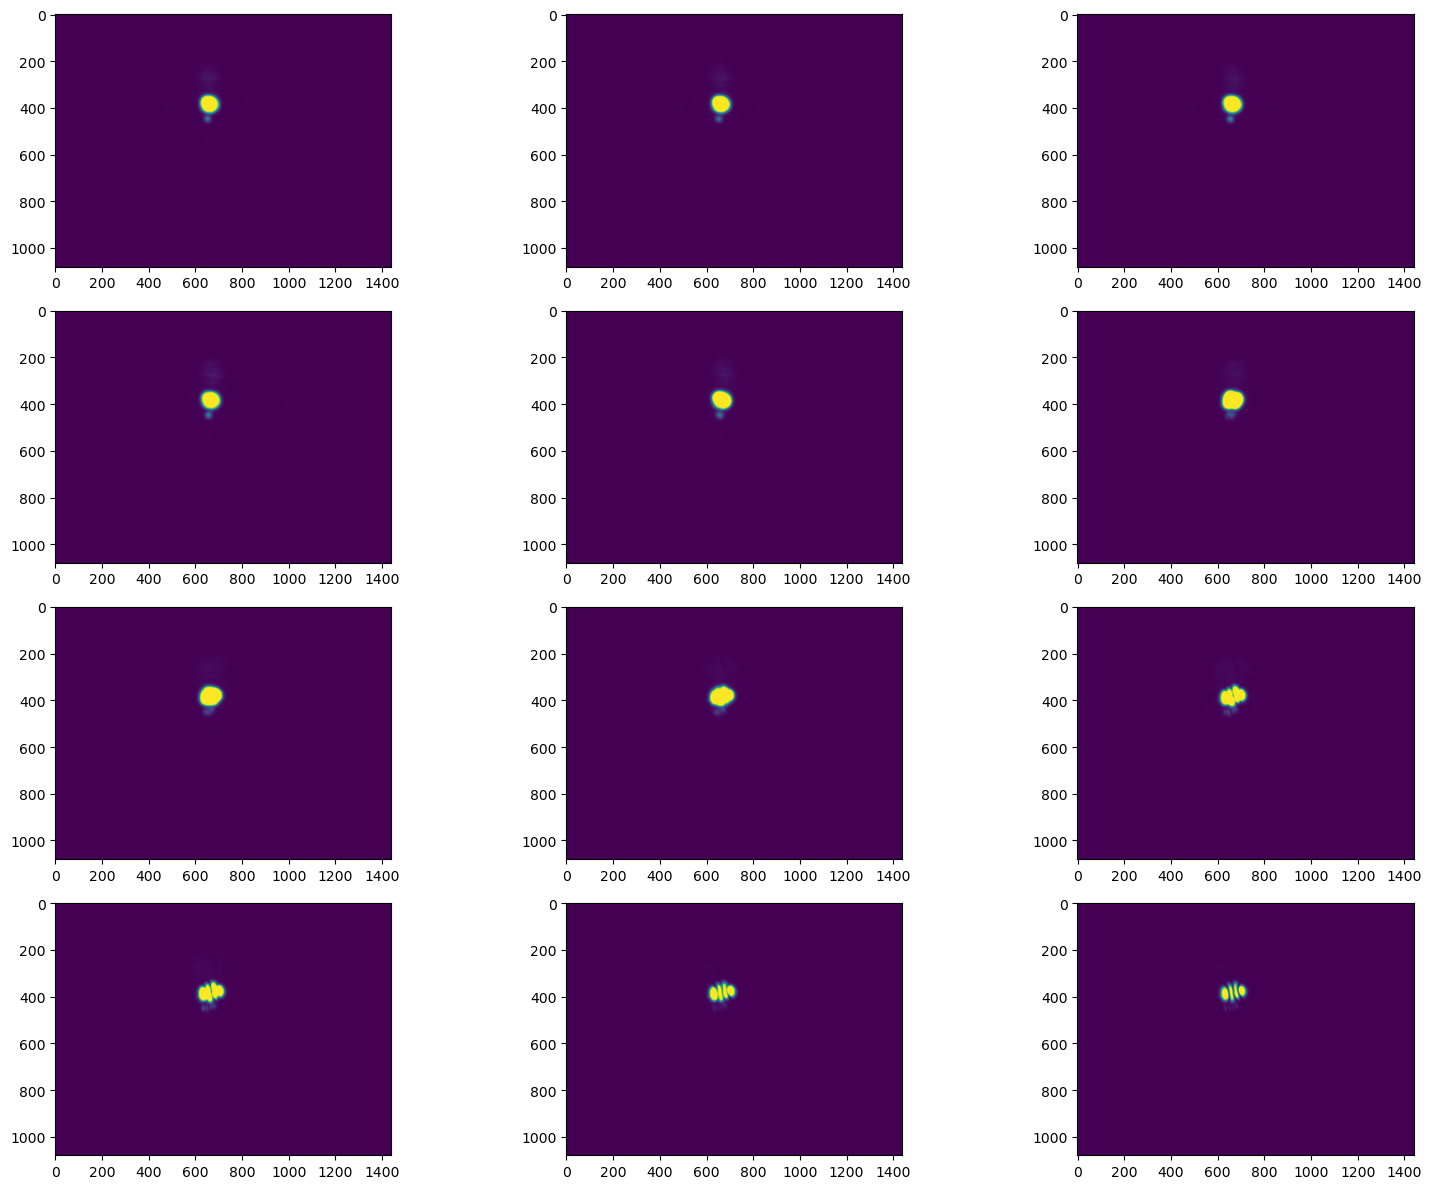

In [57]:
fig = plt.figure(figsize=[16, 12])

for i, img in enumerate(img_files):
    ax = fig.add_subplot(4,3,i+1)
    pic = cv2.imread(img, 0)
    ax.imshow(pic)
    
fig.tight_layout()
plt.show()


In [62]:
wavelengths = [930, 940, 950, 960]
modes = [[0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 1, 1], [0, 0, 0, 0, 0, 1, 1, 3, 3, 3, 3, 3], [0, 0, 0, 0, 0, 0, 1, 1, 2, 2, 2]]

#940
mode = [0, 0, 0, 0, 0, 0, 0, 1, 1]

#960
mode = [0, 0, 0, 0, 0, 0, 1, 1, 2, 2, 2]

#930
mode = [0, 0, 0, 0, 0, 0]

#950
mode = [0, 0, 0, 0, 0, 1, 1, 3, 3, 3, 3, 3]

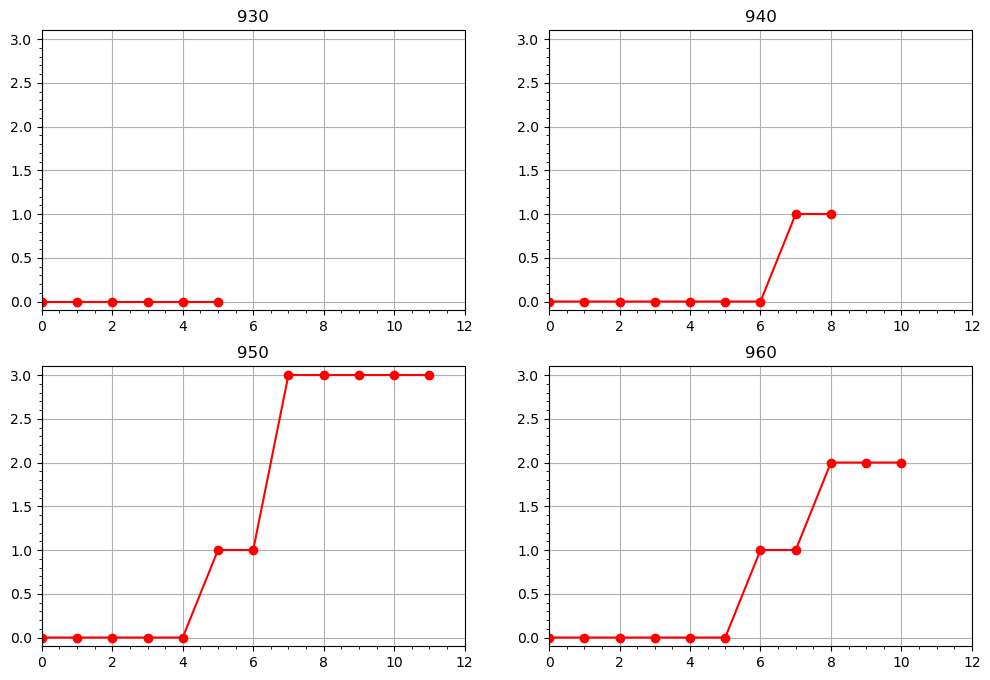

In [72]:
fig = plt.figure(figsize=[12, 8])


for i, wavelength in enumerate(wavelengths):
     ax = fig.add_subplot(2,2,i+1)
     ax.plot(modes[i], '-ro')
     ax.set_title(wavelength)
     ax.set_xlim(0, 12)
     ax.set_ylim(-0.1, 3.1)
     ax.minorticks_on()
     ax.grid()

plt.show()